# LLM WorkFlow using Lang Graph

**Create a simple Q&A chatbot that interacts directly with an LLM, without using RAG, a vector database, or any external tools.**

In [3]:
#Define Library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from google import genai
import os
from dotenv import load_dotenv

In [82]:
#install package
#pip install genai

In [11]:
#load api key from environment
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-3.5-flash")  

if not GEMINI_API_KEY:
    raise RuntimeError("GEMINI_API_KEY is not set in the .env file.")
# else:


In [12]:
#test LLM
client = genai.Client(api_key=GEMINI_API_KEY)

def ask_gemini(prompt):
    response = client.models.generate_content(
        model="gemini-3.7-flash",
        contents=prompt
    )
    return response.text

answer = ask_gemini("What is RAG in Generative AI in one sentence?")
print(answer)

**Retrieval-Augmented Generation (RAG)** is a technique that enhances generative AI models by retrieving relevant information from external knowledge sources to produce more accurate, up-to-date, and contextually grounded responses.


In [89]:
#Define State
class llm_state(TypedDict):
    question: str
    answer: str

In [90]:
def llm_qa(state:llm_state) -> llm_state:
    question = state['question']
    answer = client.models.generate_content(model="gemini-3.7-flash", contents=question).text
    #update state
    state['answer']=answer

    return state

In [95]:
#Define graph
graph=StateGraph(llm_state) #create object for graph

#add notes to the graph
#Create a node called calculate_bmi and execute the calculate_bmi function when this node runs.
graph.add_node('LLM_QA',llm_qa)

#add edges to the graph
graph.add_edge(START,'LLM_QA')
graph.add_edge('LLM_QA',END)

#compile the graph
workflow=graph.compile()

#execute the graph
initial_state = {'question':"Capital of United State"}
final_state=workflow.invoke(initial_state)
print(final_state['answer'])

The capital of the United States is **Washington, D.C.**


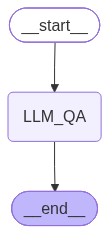

In [61]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())